# Memory Crossover: KV Cache vs Recurrent State
Plots memory usage as a function of sequence length for standard KV cache versus fixed-size recurrent state (streaming attention).

**No GPU required** - pure calculation based on Llama-3.1-8B-Instruct architecture.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Llama-3.1-8B-Instruct architecture
num_layers = 32
num_kv_heads = 8       # GQA: 8 KV heads
head_dim = 128
bytes_per_param = 2    # FP16

# DuoAttention: ~50% of heads are streaming
streaming_fraction = 0.5
num_streaming_heads = int(num_kv_heads * streaming_fraction)  # 4 heads
num_retrieval_heads = num_kv_heads - num_streaming_heads       # 4 heads

seq_lens = np.arange(1, 131073)  # 1 to 128K

In [2]:
# Standard KV cache: 2 (K+V) * num_kv_heads * seq_len * head_dim * bytes * num_layers
mem_fullkv_mb = (2 * num_kv_heads * seq_lens * head_dim * bytes_per_param * num_layers) / (1024**2)

# Streaming attention (hybrid):
# Retrieval heads keep KV cache: 2 * num_retrieval * seq_len * head_dim * bytes * layers
# Streaming heads use fixed state: num_streaming * head_dim * head_dim * bytes * layers
mem_retrieval_mb = (2 * num_retrieval_heads * seq_lens * head_dim * bytes_per_param * num_layers) / (1024**2)
mem_state_mb = (num_streaming_heads * head_dim * head_dim * bytes_per_param * num_layers) / (1024**2)  # fixed
mem_hybrid_mb = mem_retrieval_mb + mem_state_mb

# Crossover point: where hybrid becomes cheaper than full KV
# 2 * N_kv * T * d = 2 * N_ret * T * d + N_str * d * d
# 2 * N_str * T * d = N_str * d * d
# T = d / 2 = 128 / 2 = 64
crossover_T = head_dim // 2
print(f'Crossover at seq_len = {crossover_T}')
print(f'Full KV at 128K tokens: {mem_fullkv_mb[-1]:.0f} MB')
print(f'Hybrid at 128K tokens:  {mem_hybrid_mb[-1]:.0f} MB')
print(f'Savings at 128K: {(1 - mem_hybrid_mb[-1]/mem_fullkv_mb[-1])*100:.1f}%')

Crossover at seq_len = 64
Full KV at 128K tokens: 16384 MB
Hybrid at 128K tokens:  8196 MB
Savings at 128K: 50.0%


Saved to /results/memory_crossover.png


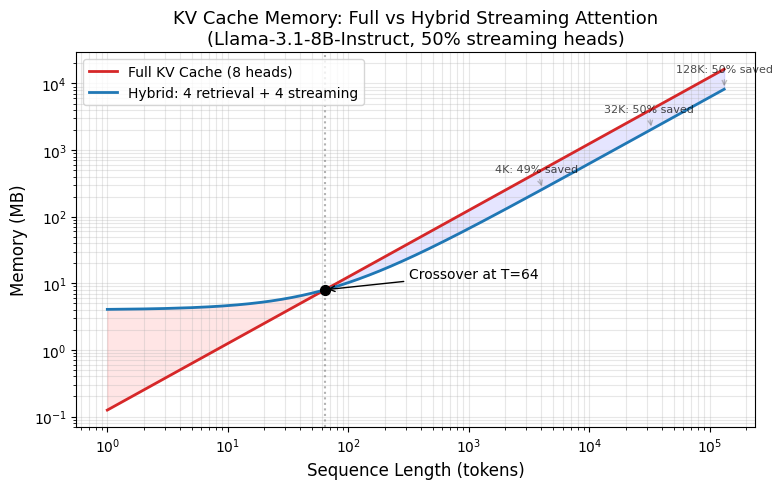

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.plot(seq_lens, mem_fullkv_mb, color='#d62728', linewidth=2, label='Full KV Cache (8 heads)')
ax.plot(seq_lens, mem_hybrid_mb, color='#1f77b4', linewidth=2, label='Hybrid: 4 retrieval + 4 streaming')

# Mark crossover
crossover_mem = mem_fullkv_mb[crossover_T - 1]
ax.axvline(x=crossover_T, color='grey', linestyle=':', alpha=0.6)
ax.scatter([crossover_T], [crossover_mem], color='black', zorder=5, s=50)
ax.annotate(f'Crossover at T={crossover_T}', (crossover_T, crossover_mem),
            xytext=(crossover_T * 5, crossover_mem * 1.5),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, ha='left')

# Mark key context lengths
for T_mark, label in [(4096, '4K'), (32768, '32K'), (131072, '128K')]:
    idx = T_mark - 1
    saving = (1 - mem_hybrid_mb[idx]/mem_fullkv_mb[idx]) * 100
    ax.annotate(f'{label}: {saving:.0f}% saved',
                (T_mark, mem_hybrid_mb[idx]),
                xytext=(T_mark * 0.4, mem_hybrid_mb[idx] * 1.8),
                fontsize=8, alpha=0.7,
                arrowprops=dict(arrowstyle='->', color='grey', alpha=0.5))

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Sequence Length (tokens)', fontsize=12)
ax.set_ylabel('Memory (MB)', fontsize=12)
ax.set_title('KV Cache Memory: Full vs Hybrid Streaming Attention\n(Llama-3.1-8B-Instruct, 50% streaming heads)', fontsize=13)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3, which='both')

# Shade regions
ax.fill_between(seq_lens[:crossover_T], mem_fullkv_mb[:crossover_T], mem_hybrid_mb[:crossover_T],
                alpha=0.1, color='red', label='_')
ax.fill_between(seq_lens[crossover_T-1:], mem_fullkv_mb[crossover_T-1:], mem_hybrid_mb[crossover_T-1:],
                alpha=0.1, color='blue', label='_')

plt.tight_layout()
save_path = Path('../results/memory_crossover.png')
save_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved to {save_path.resolve()}')
plt.show()